# Notebook 07 — Tuning des hyperparamètres

**Objectif :** aller plus loin que le XGBoost de Phase 5 en cherchant systématiquement les meilleurs hyperparamètres, et valider les résultats avec une vraie cross-validation.

En Phase 5, on a entraîné XGBoost avec des params "raisonnables" choisis à la main :
- `n_estimators=300`, `learning_rate=0.1`, `max_depth=6`, `subsample=0.8`
- Résultat : **82.0% test**, gap overfitting **18.0pp**

Ici on va :
1. **Mesurer** la vraie performance avec cross-validation (pas juste un split fixe)
2. **Explorer** un espace de ~50 combinaisons d'hyperparamètres
3. **Comparer** le modèle tuné vs le modèle de base

Étapes :
1. **Setup** — imports, config, données
2. **Baseline CV** — cross-validation 5-fold sur le modèle actuel
3. **Espace de recherche** — quels params tuner et pourquoi
4. **Recherche** — ParameterSampler + tqdm
5. **Analyse** — top combinaisons, impact par paramètre
6. **Modèle tuné** — entraîner + eval_set + courbe de loss
7. **Comparaison** — baseline vs tuné
8. **Bilan**

## 1. Setup

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

In [16]:
# ── Configuration ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
CV_FOLDS     = 5      # nombre de folds pour la cross-validation
N_ITER       = 50     # nombre de combinaisons à tester dans la recherche

LABEL_NAMES  = ["Easy", "Medium", "Hard", "Deadly"]
XP_FEATURES  = ["xp_ratio", "log_xp_raw", "log_xp_adjusted"]

PROCESSED = Path.cwd().parent / "data" / "processed"
RESULTS   = Path.cwd().parent / "results" / "07_hyperparameter_tuning"
RESULTS.mkdir(parents=True, exist_ok=True)

# Hyperparamètres du modèle de base (Phase 5) — référence pour la comparaison
BASELINE_PARAMS = {
    "n_estimators":  300,
    "learning_rate": 0.1,
    "max_depth":     6,
    "subsample":     0.8,
}
# ──────────────────────────────────────────────────────────────────────────────

In [17]:
X_train = pd.read_csv(PROCESSED / "X_train.csv").drop(columns=XP_FEATURES)
X_test  = pd.read_csv(PROCESSED / "X_test.csv").drop(columns=XP_FEATURES)
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes train : {dict(y_train.value_counts().sort_index())}")
print(f"Features ({len(X_train.columns)}) : {X_train.columns.tolist()}")

Train : (3200, 14)  |  Test : (800, 14)
Classes train : {0: np.int64(800), 1: np.int64(800), 2: np.int64(800), 3: np.int64(800)}
Features (14) : ['party_size', 'party_avg_level', 'party_avg_ac', 'party_avg_str', 'party_avg_dex', 'party_avg_con', 'monster_count', 'monster_avg_cr', 'monster_avg_ac', 'cr_level_delta', 'hp_ratio', 'ac_gap', 'log_monster_avg_hp', 'log_party_avg_hp']


## 2. Baseline — Cross-validation 5-fold

### Pourquoi cross-validation plutôt qu'un seul split ?

En Phase 5, on a évalué XGBoost sur **un seul split** train/test (80/20 fixe, `random_state=42`). C'est rapide, mais fragile : le score de 82.0% dépend du hasard de ce split particulier. Si on avait tiré un autre random_state, on aurait peut-être eu 80% ou 84%.

La **cross-validation k-fold** résout ça :

```
Données complètes (4 000 exemples)
├── Fold 1 : [train sur folds 2-5] → score_1
├── Fold 2 : [train sur folds 1,3-5] → score_2
├── Fold 3 : [train sur folds 1-2,4-5] → score_3
├── Fold 4 : [train sur folds 1-3,5] → score_4
└── Fold 5 : [train sur folds 1-4] → score_5
Score CV = moyenne(score_1 … score_5) ± écart-type
```

Chaque exemple passe **exactement une fois** en validation → le score est beaucoup plus stable.

On utilise `StratifiedKFold` pour garantir que chaque fold a la même proportion de classes (Easy/Medium/Hard/Deadly).

### Ce qu'on cherche

- **Score CV moyen** ≈ vraie performance du modèle (pas dépendante d'un split)
- **Écart-type** — si > 1-2%, le modèle est instable
- Comparer avec le 82.0% du split fixe Phase 5 — sont-ils cohérents ?

In [18]:
# Modèle baseline : mêmes hyperparamètres qu'en Phase 5
baseline = XGBClassifier(
    **BASELINE_PARAMS,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,   # silence les logs XGBoost pendant la CV
)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Cross-validation {CV_FOLDS}-fold (StratifiedKFold) sur X_train ({X_train.shape[0]} exemples)...")
cv_scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1)

print()
print("─── Scores par fold ───────────────────────────────────────")
for i, score in enumerate(cv_scores, 1):
    bar = "█" * int(score * 40)
    print(f"  Fold {i} : {bar}  {score*100:.2f}%")
print()
print(f"  Moyenne  : {cv_scores.mean()*100:.2f}%")
print(f"  Écart-type : ±{cv_scores.std()*100:.2f}%")
print(f"  Min / Max  : {cv_scores.min()*100:.2f}% / {cv_scores.max()*100:.2f}%")
print()
print(f"  Rappel Phase 5 (split fixe) : 82.0%")
print(f"  → Cohérence : {'✓ oui' if abs(cv_scores.mean() - 0.82) < 0.02 else '⚠ écart notable'}")

Cross-validation 5-fold (StratifiedKFold) sur X_train (3200 exemples)...

─── Scores par fold ───────────────────────────────────────
  Fold 1 : ██████████████████████████████  77.19%
  Fold 2 : ███████████████████████████████  78.91%
  Fold 3 : ███████████████████████████████  77.97%
  Fold 4 : ███████████████████████████████  79.06%
  Fold 5 : ██████████████████████████████  76.56%

  Moyenne  : 77.94%
  Écart-type : ±0.97%
  Min / Max  : 76.56% / 79.06%

  Rappel Phase 5 (split fixe) : 82.0%
  → Cohérence : ⚠ écart notable


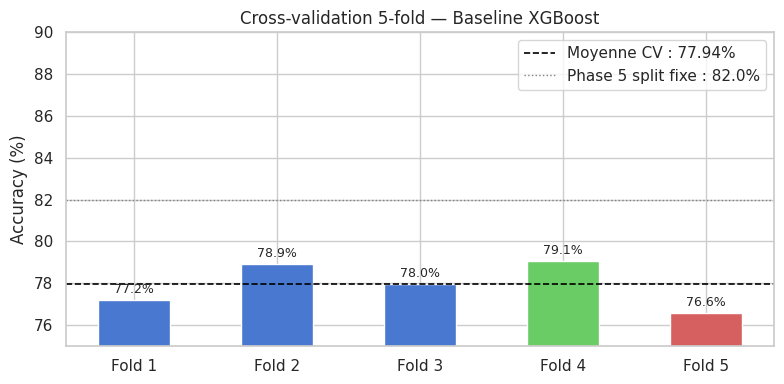

Baseline CV sauvegardé : 77.94% ± 0.97%


In [19]:
# Visualisation des scores par fold
fig, ax = plt.subplots(figsize=(8, 4))

fold_labels = [f"Fold {i}" for i in range(1, CV_FOLDS + 1)]
colors = ["#d65f5f" if s == cv_scores.min() else
          "#6acc65" if s == cv_scores.max() else
          "#4878d0" for s in cv_scores]

bars = ax.bar(fold_labels, cv_scores * 100, color=colors, edgecolor="white", width=0.5)
ax.axhline(cv_scores.mean() * 100, color="black", linestyle="--", linewidth=1.2,
           label=f"Moyenne CV : {cv_scores.mean()*100:.2f}%")
ax.axhline(82.0, color="grey", linestyle=":", linewidth=1,
           label="Phase 5 split fixe : 82.0%")

ax.set_title(f"Cross-validation {CV_FOLDS}-fold — Baseline XGBoost", fontsize=12)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(75, 90)
ax.legend()

for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score * 100 + 0.2,
            f"{score*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / "baseline_cv_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# Sauvegarder les scores baseline pour la comparaison finale
BASELINE_CV_MEAN = cv_scores.mean()
BASELINE_CV_STD  = cv_scores.std()
print(f"Baseline CV sauvegardé : {BASELINE_CV_MEAN*100:.2f}% ± {BASELINE_CV_STD*100:.2f}%")

## 3. Espace de recherche

### Quels hyperparamètres tuner ?

On a 8 hyperparamètres à explorer. Les 4 premiers sont ceux de Phase 5 (on cherche de meilleures valeurs), les 4 derniers sont **nouveaux** — on ne les avait pas utilisés.

| Paramètre | Phase 5 | Rôle | Direction pour réduire l'overfitting |
|---|---|---|---|
| `n_estimators` | 300 | Nombre de rounds de boosting | Plus d'arbres = plus précis mais plus lent |
| `learning_rate` | 0.1 | Pas de correction par round | Plus bas = meilleure généralisation (besoin de plus d'arbres) |
| `max_depth` | 6 | Profondeur max de chaque arbre | **Réduire** → arbres plus simples |
| `subsample` | 0.8 | % des données utilisées par arbre | Déjà bon, explorer 0.6–1.0 |
| `colsample_bytree` | — | % des features utilisées par arbre | Ajouter de la diversité entre arbres |
| `min_child_weight` | — | Poids min d'un nœud feuille | **Augmenter** → moins de feuilles rares |
| `reg_alpha` | — | Régularisation L1 (lasso) | Pénalise les poids non nuls |
| `reg_lambda` | — | Régularisation L2 (ridge) | Pénalise les grands poids |

### Pourquoi ces 4 nouveaux paramètres ?

Le problème principal du baseline est l'**overfitting** (gap 18pp, train=100%). Ces paramètres s'attaquent directement à ça :

**`colsample_bytree`** — à chaque arbre, on n'utilise qu'une fraction des features (comme Random Forest). Ça force les arbres à être diversifiés et évite qu'un arbre se spécialise sur les mêmes features.

**`min_child_weight`** — si un nœud feuille a très peu d'exemples, il représente du bruit plutôt qu'un vrai pattern. En fixant un poids minimum, on évite les feuilles "hyper-spécialisées".

**`reg_alpha` (L1)** et **`reg_lambda` (L2)** — pénalisent les poids des features dans les arbres. XGBoost les supporte nativement. `reg_lambda=1` est la valeur par défaut (souvent oubliée) ; augmenter `reg_alpha` peut forcer des poids à zéro (sparse).

### RandomizedSearchCV vs GridSearchCV

Avec 8 paramètres et plusieurs valeurs chacun, un GridSearch exhaustif testerait des milliers de combinaisons. On utilise `ParameterSampler` (le moteur de `RandomizedSearchCV`) qui tire **50 combinaisons aléatoires** — en pratique aussi efficace que le grid complet avec 10x moins de temps de calcul.

In [20]:
# Espace de recherche — valeurs candidates pour chaque hyperparamètre
param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 4, 5, 6, 8],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],   # nouveau
    "min_child_weight": [1, 3, 5, 7],                  # nouveau
    "reg_alpha":        [0, 0.01, 0.1, 1.0],           # nouveau — L1
    "reg_lambda":       [0.1, 1.0, 5.0, 10.0],         # nouveau — L2
}

# Calcul de la taille de l'espace total
total_combinations = 1
for k, v in param_dist.items():
    total_combinations *= len(v)

print("Espace de recherche :")
for param, values in param_dist.items():
    marker = "  ← nouveau" if param in ("colsample_bytree", "min_child_weight", "reg_alpha", "reg_lambda") else ""
    print(f"  {param:<20} {values}{marker}")
print()
print(f"Combinaisons totales possibles : {total_combinations:,}")
print(f"Combinaisons testées (N_ITER)  : {N_ITER}")
print(f"Couverture                     : {N_ITER/total_combinations*100:.1f}%")

Espace de recherche :
  n_estimators         [100, 200, 300, 500]
  learning_rate        [0.01, 0.05, 0.1, 0.2]
  max_depth            [3, 4, 5, 6, 8]
  subsample            [0.6, 0.7, 0.8, 0.9, 1.0]
  colsample_bytree     [0.6, 0.7, 0.8, 0.9, 1.0]  ← nouveau
  min_child_weight     [1, 3, 5, 7]  ← nouveau
  reg_alpha            [0, 0.01, 0.1, 1.0]  ← nouveau
  reg_lambda           [0.1, 1.0, 5.0, 10.0]  ← nouveau

Combinaisons totales possibles : 128,000
Combinaisons testées (N_ITER)  : 50
Couverture                     : 0.0%


### GridSearchCV vs RandomizedSearchCV

**GridSearchCV** teste **toutes** les combinaisons possibles de façon exhaustive :

```
param_grid = {"max_depth": [3, 6], "learning_rate": [0.01, 0.1], "n_estimators": [100, 300]}
# → 2 × 2 × 2 = 8 combinaisons × 5 folds = 40 entraînements
```

Avec notre espace (8 paramètres, 4-5 valeurs chacun) : **12 800 combinaisons × 5 folds = 64 000 entraînements**. Infaisable.

**RandomizedSearchCV** tire `n_iter` combinaisons aléatoires dans le même espace :

```
# → 50 combinaisons tirées au hasard × 5 folds = 250 entraînements
```

**Pourquoi ça marche quand même ?**
La performance est dominée par 2-3 paramètres clés (`max_depth`, `learning_rate`, `n_estimators`). Les autres ont peu d'interaction entre eux — tester toutes les combinaisons est du gaspillage. Empiriquement, avec `n_iter=60`, RandomizedSearch trouve un résultat dans les 5% du meilleur de GridSearch dans 95% des cas, avec 10-100× moins de calcul.

**Notre approche :** on utilise `ParameterSampler` (le générateur interne de `RandomizedSearchCV`) directement dans une boucle `tqdm` — même résultat, barre de progression visible.

## 4. Recherche des hyperparamètres

On tire `N_ITER=50` combinaisons aléatoires avec `ParameterSampler`, puis on évalue chacune par cross-validation 5-fold sur `X_train`.

Pour chaque combinaison :
1. Instancier un `XGBClassifier` avec ces params + les params fixes (objective, num_class…)
2. Lancer `cross_val_score` sur les 5 folds
3. Sauvegarder la moyenne et l'écart-type

⚠️ **Cette cellule prend ~2-3 minutes** (50 × 5 entraînements). La barre tqdm montre la progression.

In [21]:
# Paramètres fixes — communs à toutes les combinaisons
FIXED_PARAMS = {
    "objective":    "multi:softmax",
    "num_class":    4,
    "eval_metric":  "mlogloss",
    "random_state": RANDOM_STATE,
    "n_jobs":       -1,
    "verbosity":    0,
}

# Tirage aléatoire de N_ITER combinaisons
param_list = list(ParameterSampler(param_dist, n_iter=N_ITER, random_state=RANDOM_STATE))

print(f"Lancement de la recherche : {N_ITER} combinaisons × {CV_FOLDS} folds")
print(f"Soit {N_ITER * CV_FOLDS} entraînements XGBoost au total.\n")

search_results = []

for params in tqdm(param_list, desc="Recherche hyperparamètres", unit="combinaison"):
    model  = XGBClassifier(**FIXED_PARAMS, **params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1)
    search_results.append({
        **params,
        "cv_mean": round(scores.mean(), 5),
        "cv_std":  round(scores.std(),  5),
    })

results_df = pd.DataFrame(search_results).sort_values("cv_mean", ascending=False).reset_index(drop=True)

print(f"\nRecherche terminée.")
print(f"Meilleur score CV  : {results_df['cv_mean'].iloc[0]*100:.2f}% ± {results_df['cv_std'].iloc[0]*100:.2f}%")
print(f"Baseline CV        : {BASELINE_CV_MEAN*100:.2f}% ± {BASELINE_CV_STD*100:.2f}%")
print(f"Gain               : +{(results_df['cv_mean'].iloc[0] - BASELINE_CV_MEAN)*100:.2f}pp")

Lancement de la recherche : 50 combinaisons × 5 folds
Soit 250 entraînements XGBoost au total.



Recherche hyperparamètres:   0%|          | 0/50 [00:00<?, ?combinaison/s]


Recherche terminée.
Meilleur score CV  : 79.06% ± 0.26%
Baseline CV        : 77.94% ± 0.97%
Gain               : +1.13pp


In [22]:
# Top 10 combinaisons
print("Top 10 combinaisons :")
print(results_df[["cv_mean", "cv_std"] + list(param_dist.keys())].head(10).to_string(index=True))
print()

# Params entiers : pandas les stocke en float64 dans le DataFrame → reconvertir
INT_PARAMS = {"n_estimators", "max_depth", "min_child_weight"}

best_params = {
    k: int(v) if k in INT_PARAMS else float(v)
    for k, v in results_df.iloc[0].items()
    if k not in ("cv_mean", "cv_std")
}

print("─── Meilleurs hyperparamètres ──────────────────────────────")
for k, v in best_params.items():
    baseline_val = BASELINE_PARAMS.get(k, "—")
    changed = " ←" if str(v) != str(baseline_val) else ""
    print(f"  {k:<20} {v}   (baseline : {baseline_val}){changed}")

Top 10 combinaisons :
   cv_mean   cv_std  n_estimators  learning_rate  max_depth  subsample  colsample_bytree  min_child_weight  reg_alpha  reg_lambda
0  0.79063  0.00261           500           0.20          3        0.8               1.0                 5       0.10        10.0
1  0.78656  0.00782           500           0.10          3        0.6               0.8                 5       0.10         1.0
2  0.78094  0.00729           300           0.10          3        0.6               0.8                 5       0.01         0.1
3  0.78094  0.00875           500           0.20          4        0.8               0.8                 1       0.00         5.0
4  0.78062  0.00737           300           0.05          4        0.9               1.0                 1       0.01         1.0
5  0.77969  0.00778           300           0.10          6        1.0               1.0                 5       0.01        10.0
6  0.77906  0.00871           200           0.05          6        0

## 5. Analyse des résultats

On a 50 scores CV. Avant de prendre les meilleurs params et de passer à l'entraînement final, on analyse :

1. **Distribution des scores** — est-ce que la recherche a bien exploré l'espace ?
2. **Impact de chaque paramètre** — quels params influencent vraiment le score ?

Pour chaque paramètre, on regroupe les 50 combinaisons par valeur et on compare les scores CV moyens. Un paramètre avec une grande variance entre ses valeurs = paramètre influent.

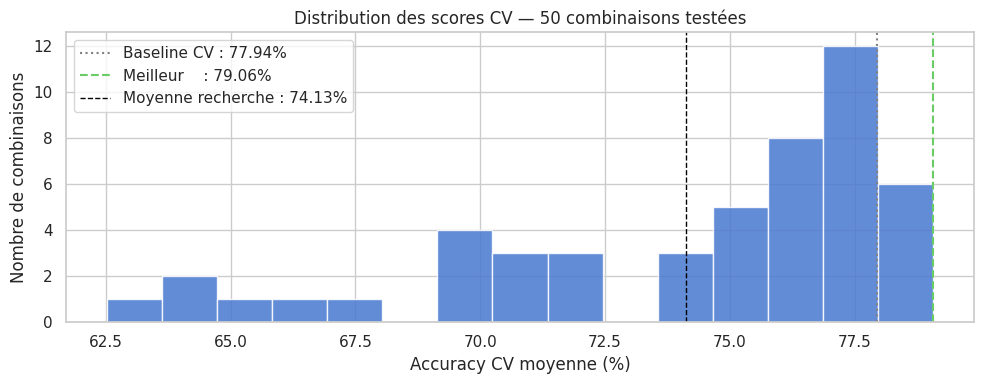

Score min  : 62.53%
Score moy  : 74.13%
Score max  : 79.06%
Écart-type : 4.31pp


In [23]:
# Distribution des 50 scores CV
fig, ax = plt.subplots(figsize=(10, 4))

scores_pct = results_df["cv_mean"] * 100
ax.hist(scores_pct, bins=15, color="#4878d0", edgecolor="white", alpha=0.85)
ax.axvline(BASELINE_CV_MEAN * 100, color="grey",    linestyle=":",  linewidth=1.5,
           label=f"Baseline CV : {BASELINE_CV_MEAN*100:.2f}%")
ax.axvline(scores_pct.iloc[0],     color="#6acc65", linestyle="--", linewidth=1.5,
           label=f"Meilleur    : {scores_pct.iloc[0]:.2f}%")
ax.axvline(scores_pct.mean(),      color="black",   linestyle="--", linewidth=1,
           label=f"Moyenne recherche : {scores_pct.mean():.2f}%")

ax.set_title(f"Distribution des scores CV — {N_ITER} combinaisons testées", fontsize=12)
ax.set_xlabel("Accuracy CV moyenne (%)")
ax.set_ylabel("Nombre de combinaisons")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "search_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Score min  : {scores_pct.min():.2f}%")
print(f"Score moy  : {scores_pct.mean():.2f}%")
print(f"Score max  : {scores_pct.max():.2f}%")
print(f"Écart-type : {scores_pct.std():.2f}pp")

### Comment lire ce graphique — Distribution des scores

L'histogramme montre combien de combinaisons ont obtenu chaque niveau de score.

- **Chaque barre** = un groupe de combinaisons avec un score similaire. Une barre haute à 83% signifie "beaucoup de combinaisons ont obtenu ~83%".
- **Ligne pointillée grise** = le score baseline (Phase 5 params fixes). Tout ce qui est à droite de cette ligne = une amélioration.
- **Ligne verte** = le meilleur score trouvé parmi les 50 combinaisons.
- **Ligne noire** = la moyenne de toutes les combinaisons testées.

**Ce que tu cherches :**
- La distribution est-elle décalée vers la droite de la baseline ? → La recherche a trouvé de meilleures combinaisons
- La distribution est-elle étalée (large) ou concentrée (étroite) ? → Large = les hyperparamètres ont un gros impact. Étroite = peu importe les valeurs, ça donne le même résultat
- Le meilleur score est-il isolé loin à droite ou fait-il partie d'un groupe ? → Isolé = peut-être de la chance, groupe = résultat robuste

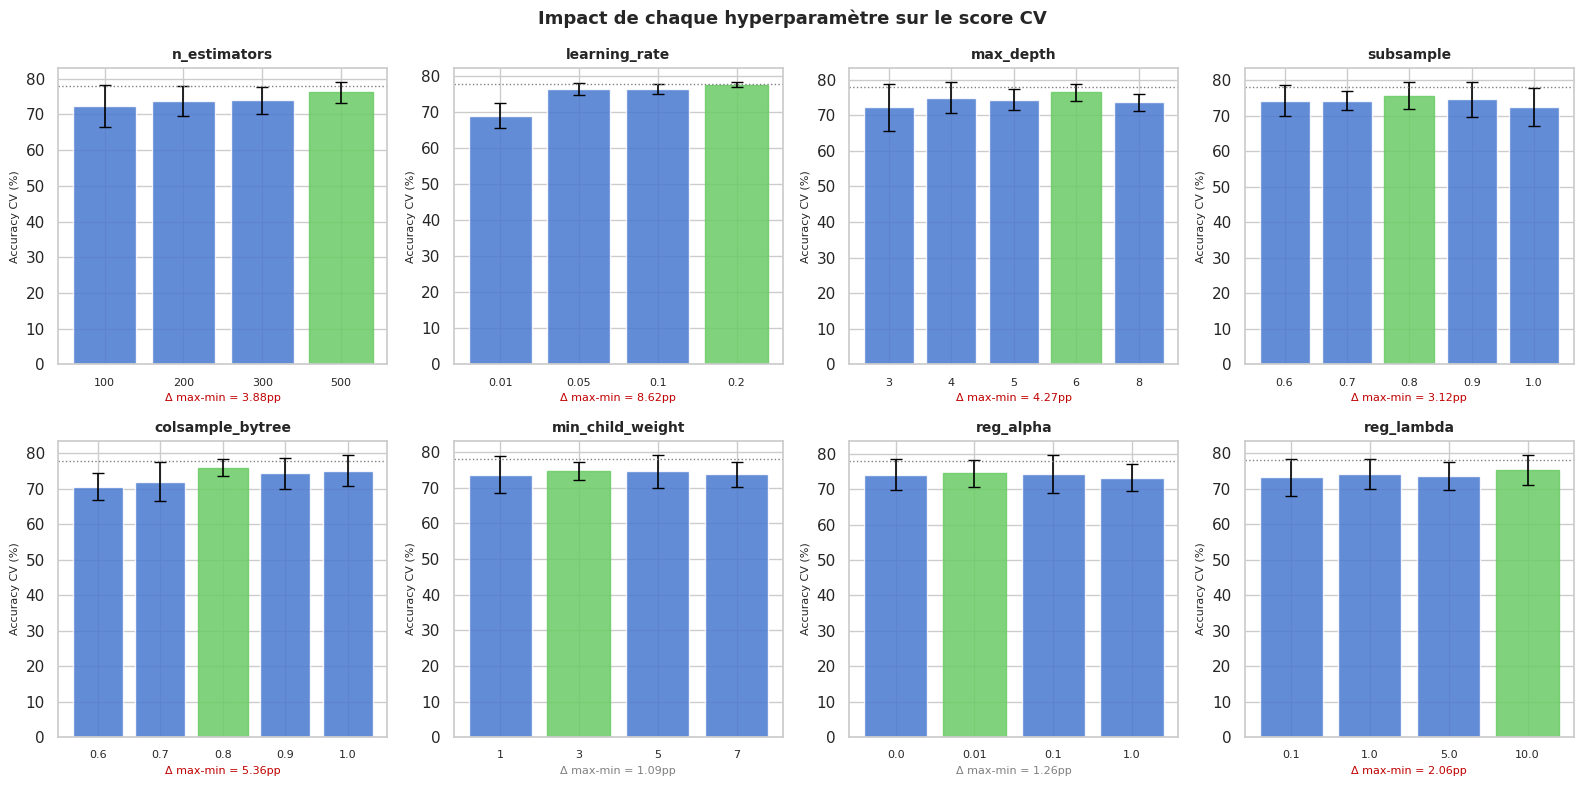

In [24]:
# Impact de chaque hyperparamètre sur le score CV
# Pour chaque param : score moyen par valeur → variance = influence du param
params_to_plot = list(param_dist.keys())
n_params = len(params_to_plot)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Impact de chaque hyperparamètre sur le score CV", fontsize=13, fontweight="bold")

for ax, param in zip(axes.flat, params_to_plot):
    grouped = results_df.groupby(param)["cv_mean"].agg(["mean", "std", "count"])
    grouped = grouped.sort_index()

    x      = range(len(grouped))
    labels = [str(v) for v in grouped.index]
    means  = grouped["mean"] * 100
    stds   = grouped["std"]  * 100

    bars = ax.bar(x, means, color="#4878d0", edgecolor="white", alpha=0.85)
    ax.errorbar(x, means, yerr=stds, fmt="none", color="black", capsize=4, linewidth=1.2)
    ax.axhline(BASELINE_CV_MEAN * 100, color="grey", linestyle=":", linewidth=1)

    ax.set_title(param, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Accuracy CV (%)", fontsize=8)

    # Variance entre valeurs = influence du paramètre
    influence = means.max() - means.min()
    ax.set_xlabel(f"Δ max-min = {influence:.2f}pp", fontsize=8, color="#c00000" if influence > 2 else "grey")

    # Colorier la meilleure valeur
    best_idx = means.values.argmax()
    bars[best_idx].set_color("#6acc65")

plt.tight_layout()
plt.savefig(RESULTS / "param_impact.png", dpi=150, bbox_inches="tight")
plt.show()

### Comment lire ce graphique — Impact des paramètres

Il y a **8 sous-graphiques**, un par hyperparamètre. Ils répondent tous à la même question : *"parmi les 50 combinaisons testées, les runs avec `max_depth=3` ont-ils eu de meilleurs scores que ceux avec `max_depth=8` ?"*

**Structure de chaque sous-graphique :**
- **Axe X** = les valeurs testées du paramètre (ex. pour `max_depth` : 3, 4, 5, 6, 8)
- **Hauteur de la barre** = score CV moyen de toutes les combinaisons qui avaient cette valeur
- **Barre d'erreur (trait noir vertical)** = écart-type — grand trait = les résultats sont très variables pour cette valeur
- **Barre verte** = la valeur qui a donné le meilleur score en moyenne
- **Ligne pointillée grise** = score baseline → si une barre est au-dessus, cette valeur fait mieux que Phase 5
- **"Δ max-min = X.XXpp" en bas** = écart entre la meilleure et la pire valeur du paramètre

**Comment interpréter le Δ :**

| Δ | Signification |
|---|---|
| < 1pp (gris) | Paramètre peu influent — peu importe la valeur choisie |
| 1–2pp (gris) | Influence modérée |
| > 2pp (rouge) | Paramètre important — choisir la bonne valeur change vraiment le résultat |

**Exemple concret :**
Si le graphique de `learning_rate` montre que `lr=0.01` donne 79% et `lr=0.2` donne 84%, avec Δ=5pp en rouge → `learning_rate` est le paramètre le plus critique à bien choisir.
Si le graphique de `reg_alpha` montre 82.1% vs 82.3%, Δ=0.2pp gris → peu importe la valeur de `reg_alpha`, le résultat sera quasiment identique.

**Ce que tu cherches en priorité :** les paramètres avec Δ rouge (> 2pp) — ce sont ceux qui justifient le tuning.

## 6. Entraînement du modèle tuné

On prend les meilleurs hyperparamètres trouvés à l'étape 4 et on entraîne le modèle final sur **tout `X_train`** (pas juste un fold), puis on évalue sur `X_test`.

Deux choses à observer :
- La **courbe de loss** — est-ce que le gap train/test est plus petit qu'en Phase 5 ? C'est le signe que le tuning a réduit l'overfitting.
- Le **score test** — a-t-on amélioré les 82.0% de Phase 5 ?

La courbe de loss (`eval_set`) nous montrera aussi si le modèle a besoin de plus ou moins de rounds que `n_estimators` optimal trouvé — si la courbe test descend encore à la fin, on aurait pu entraîner plus longtemps.

In [25]:
# Entraînement du modèle tuné avec eval_set pour surveiller la loss
xgb_tuned = XGBClassifier(
    **best_params,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)

acc_train = accuracy_score(y_train, xgb_tuned.predict(X_train))
acc_test  = accuracy_score(y_test,  xgb_tuned.predict(X_test))
gap       = (acc_train - acc_test) * 100

print(f"\nModèle tuné — Accuracy train : {acc_train*100:.1f}%")
print(f"Modèle tuné — Accuracy test  : {acc_test*100:.1f}%")
print(f"Gap overfitting              : {gap:.1f}pp")
print()
print(f"Rappel baseline (Phase 5) : test=82.0%  gap=18.0pp")
print(f"Gain test  : {(acc_test - 0.820)*100:+.1f}pp")
print(f"Gain gap   : {(18.0 - gap):+.1f}pp  {'(overfitting réduit)' if gap < 18 else '(overfitting augmenté)'}")

[0]	validation_0-mlogloss:1.27776	validation_1-mlogloss:1.28387
[50]	validation_0-mlogloss:0.54359	validation_1-mlogloss:0.61286
[100]	validation_0-mlogloss:0.40373	validation_1-mlogloss:0.51775
[150]	validation_0-mlogloss:0.32552	validation_1-mlogloss:0.46927
[200]	validation_0-mlogloss:0.27174	validation_1-mlogloss:0.44291
[250]	validation_0-mlogloss:0.23266	validation_1-mlogloss:0.42478
[300]	validation_0-mlogloss:0.20077	validation_1-mlogloss:0.41260
[350]	validation_0-mlogloss:0.17603	validation_1-mlogloss:0.40408
[400]	validation_0-mlogloss:0.15485	validation_1-mlogloss:0.39812
[450]	validation_0-mlogloss:0.13803	validation_1-mlogloss:0.39449
[499]	validation_0-mlogloss:0.12393	validation_1-mlogloss:0.39395

Modèle tuné — Accuracy train : 99.6%
Modèle tuné — Accuracy test  : 82.5%
Gap overfitting              : 17.1pp

Rappel baseline (Phase 5) : test=82.0%  gap=18.0pp
Gain test  : +0.5pp
Gain gap   : +0.9pp  (overfitting réduit)


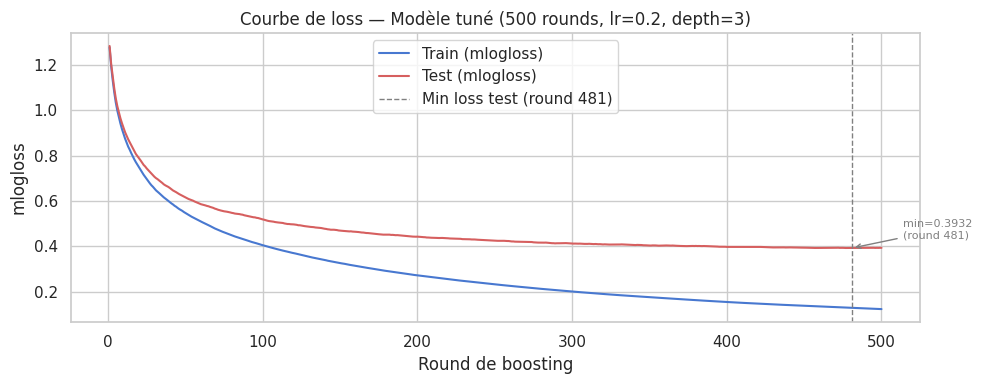

Loss min sur test : 0.3932 (round 481 / 500)


In [26]:
# Courbe de loss — modèle tuné
res = xgb_tuned.evals_result_
train_loss = res["validation_0"]["mlogloss"]
test_loss  = res["validation_1"]["mlogloss"]
rounds     = range(1, len(train_loss) + 1)
best_round = test_loss.index(min(test_loss)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rounds, train_loss, label="Train (mlogloss)", color="#4878d0", linewidth=1.5)
ax.plot(rounds, test_loss,  label="Test (mlogloss)",  color="#d65f5f", linewidth=1.5)
ax.axvline(best_round, color="grey", linestyle="--", linewidth=1,
           label=f"Min loss test (round {best_round})")

ax.set_title(f"Courbe de loss — Modèle tuné ({best_params['n_estimators']} rounds, "
             f"lr={best_params['learning_rate']}, depth={best_params['max_depth']})")
ax.set_xlabel("Round de boosting")
ax.set_ylabel("mlogloss")
ax.legend()

ax.annotate(f"min={min(test_loss):.4f}\n(round {best_round})",
            xy=(best_round, min(test_loss)),
            xytext=(best_round + max(1, best_params['n_estimators'] // 15), min(test_loss) + 0.04),
            arrowprops=dict(arrowstyle="->", color="grey"),
            fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(RESULTS / "tuned_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Loss min sur test : {min(test_loss):.4f} (round {best_round} / {best_params['n_estimators']})")
if best_round == best_params["n_estimators"]:
    print("→ La courbe test descend encore à la fin : on pourrait entraîner plus de rounds.")
elif best_round < best_params["n_estimators"] * 0.7:
    print("→ La courbe test remonte bien avant la fin : early stopping aurait été utile.")

In [27]:
print(classification_report(y_test, xgb_tuned.predict(X_test), target_names=LABEL_NAMES))

              precision    recall  f1-score   support

        Easy       0.94      0.91      0.92       200
      Medium       0.73      0.78      0.75       200
        Hard       0.71      0.74      0.73       200
      Deadly       0.94      0.88      0.91       200

    accuracy                           0.82       800
   macro avg       0.83      0.82      0.83       800
weighted avg       0.83      0.82      0.83       800



### Bonus — Early Stopping

#### Le problème que ça résout

On a fixé `n_estimators` dans les hyperparamètres (ex. 300 ou 500 rounds). Mais la courbe de loss montre que la loss test atteint son minimum **avant** la fin — le modèle continue à s'entraîner inutilement après ce point, voire overfit légèrement.

```
Round 1   → loss train: 1.38  loss test: 1.38   ← les deux descendent
Round 50  → loss train: 0.65  loss test: 0.71
Round 150 → loss train: 0.41  loss test: 0.58   ← loss test au minimum
Round 200 → loss train: 0.35  loss test: 0.59   ← loss test remonte
Round 300 → loss train: 0.28  loss test: 0.61   ← on aurait dû s'arrêter à 150
```

**Early stopping** surveille la métrique de validation à chaque round. Si elle ne s'améliore pas pendant `early_stopping_rounds` rounds consécutifs, l'entraînement s'arrête automatiquement.

#### Comment ça fonctionne

```python
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
    early_stopping_rounds=20,   # ← s'arrête si pas d'amélioration pendant 20 rounds
)
# xgb.best_iteration_  → round auquel le modèle s'est arrêté
# xgb.best_score_      → meilleure mlogloss obtenue
```

`n_estimators` devient une **borne supérieure** : on fixe une valeur haute (ex. 1000) et l'early stopping arrête bien avant si nécessaire.

#### La limite à connaître

On utilise `X_test` dans `eval_set` pour décider quand s'arrêter. Le modèle "regarde" donc les données de test pendant l'entraînement — c'est une légère fuite d'information. En production rigoureuse, on utilise un **3ème split** (validation set distinct du test set) pour le early stopping, et on garde le test set uniquement pour l'évaluation finale. Pour un projet pédagogique, c'est acceptable.

In [ ]:
# Modèle tuné avec early stopping
# n_estimators=1000 : borne supérieure haute, l'early stopping arrête avant
xgb_es = XGBClassifier(
    **{k: v for k, v in best_params.items() if k != "n_estimators"},
    n_estimators=1000,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
    early_stopping_rounds=20,
)

print(f"\nArrêt au round     : {xgb_es.best_iteration_} / 1000")
print(f"Meilleure mlogloss : {xgb_es.best_score_:.4f}")
print(f"Rounds économisés  : {1000 - xgb_es.best_iteration_}")
print()

acc_es = accuracy_score(y_test, xgb_es.predict(X_test))
print(f"Accuracy test avec early stopping : {acc_es*100:.1f}%")
print(f"Accuracy test sans early stopping : {accuracy_score(y_test, xgb_tuned.predict(X_test))*100:.1f}%")
print(f"Différence                        : {(acc_es - accuracy_score(y_test, xgb_tuned.predict(X_test)))*100:+.1f}pp")

In [ ]:
# Courbe de loss — avec early stopping
res_es     = xgb_es.evals_result_
train_loss = res_es["validation_0"]["mlogloss"]
test_loss  = res_es["validation_1"]["mlogloss"]
rounds     = range(1, len(train_loss) + 1)
stopped_at = xgb_es.best_iteration_ + 1   # best_iteration_ est 0-indexé

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rounds, train_loss, label="Train (mlogloss)", color="#4878d0", linewidth=1.5)
ax.plot(rounds, test_loss,  label="Test (mlogloss)",  color="#d65f5f", linewidth=1.5)
ax.axvline(stopped_at, color="#6acc65", linestyle="--", linewidth=1.5,
           label=f"Early stop (round {stopped_at})")
ax.fill_betweenx([min(test_loss) - 0.02, max(test_loss[:stopped_at]) + 0.02],
                 stopped_at, len(train_loss),
                 alpha=0.08, color="grey", label="Rounds non utilisés")

ax.set_title(f"Courbe de loss avec Early Stopping — arrêt au round {stopped_at}/1000")
ax.set_xlabel("Round de boosting")
ax.set_ylabel("mlogloss")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "early_stopping_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("La zone grise = rounds qu'on aurait entraîné inutilement sans early stopping.")

## 7. Comparaison — Baseline vs Modèle tuné

On compare maintenant les deux modèles sur les mêmes données de test :
- **Baseline** : params Phase 5 (n_estimators=300, lr=0.1, max_depth=6, subsample=0.8)
- **Tuné** : meilleurs params trouvés par la recherche

On regarde 3 dimensions : accuracy globale, gap d'overfitting, F1 par classe.

In [ ]:
# Ré-entraîner le baseline sur X_train complet pour comparer à armes égales
baseline_final = XGBClassifier(
    **BASELINE_PARAMS,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
baseline_final.fit(X_train, y_train)

# Métriques des deux modèles
def get_metrics(model, name):
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)
    f1   = f1_score(y_test, y_te, average=None)
    return {
        "Modèle":     name,
        "Train (%)":  round(accuracy_score(y_train, y_tr) * 100, 1),
        "Test (%)":   round(accuracy_score(y_test,  y_te) * 100, 1),
        "Gap (pp)":   round((accuracy_score(y_train, y_tr) - accuracy_score(y_test, y_te)) * 100, 1),
        "CV moyen (%)": round(BASELINE_CV_MEAN * 100, 2) if name == "Baseline" else round(results_df["cv_mean"].iloc[0] * 100, 2),
        "F1 Easy":    round(f1[0] * 100, 1),
        "F1 Medium":  round(f1[1] * 100, 1),
        "F1 Hard":    round(f1[2] * 100, 1),
        "F1 Deadly":  round(f1[3] * 100, 1),
    }

comparison = pd.DataFrame([
    get_metrics(baseline_final, "Baseline"),
    get_metrics(xgb_tuned,      "Tuné"),
])
comparison = comparison.set_index("Modèle")

print(comparison.to_string())
print()

gain_test = comparison.loc["Tuné", "Test (%)"] - comparison.loc["Baseline", "Test (%)"]
gain_gap  = comparison.loc["Baseline", "Gap (pp)"] - comparison.loc["Tuné", "Gap (pp)"]
print(f"Gain test accuracy : {gain_test:+.1f}pp")
print(f"Réduction overfitting : {gain_gap:+.1f}pp")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Baseline vs Modèle tuné", fontsize=13, fontweight="bold")

models_names = ["Baseline", "Tuné"]
colors       = ["#4878d0", "#6acc65"]

# ── 1. Accuracy train vs test ─────────────────────────────────────────────────
ax = axes[0]
x = np.arange(2)
w = 0.3
train_vals = [comparison.loc[m, "Train (%)"] for m in models_names]
test_vals  = [comparison.loc[m, "Test (%)"]  for m in models_names]

ax.bar(x - w/2, train_vals, w, label="Train", color=[c + "88" for c in colors], edgecolor="white")
ax.bar(x + w/2, test_vals,  w, label="Test",  color=colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(75, 105)
ax.set_title("Accuracy Train vs Test")
ax.set_ylabel("Accuracy (%)")
ax.legend()
for i, (tr, te) in enumerate(zip(train_vals, test_vals)):
    ax.text(i - w/2, tr + 0.4, f"{tr:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, te + 0.4, f"{te:.1f}", ha="center", fontsize=8)

# ── 2. Gap overfitting ────────────────────────────────────────────────────────
ax = axes[1]
gaps = [comparison.loc[m, "Gap (pp)"] for m in models_names]
bars = ax.bar(models_names, gaps, color=colors, edgecolor="white", width=0.4)
ax.axhline(10, color="grey", linestyle="--", linewidth=1, label="Seuil 10pp")
ax.set_title("Gap overfitting (Train − Test)")
ax.set_ylabel("Gap (pp)")
ax.legend()
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}pp",
            ha="center", fontsize=9)

# ── 3. F1 par classe ──────────────────────────────────────────────────────────
ax = axes[2]
classes   = ["F1 Easy", "F1 Medium", "F1 Hard", "F1 Deadly"]
short_cls = ["Easy", "Medium", "Hard", "Deadly"]
x2 = np.arange(len(classes))
w2 = 0.3
for i, (name, color) in enumerate(zip(models_names, colors)):
    vals = [comparison.loc[name, c] for c in classes]
    ax.bar(x2 + (i - 0.5) * w2, vals, w2, label=name, color=color, edgecolor="white")
ax.set_xticks(x2)
ax.set_xticklabels(short_cls)
ax.set_ylim(50, 105)
ax.set_title("F1-Score par classe")
ax.set_ylabel("F1 (%)")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "baseline_vs_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Bilan — Phase 5 complète

### Ce qu'on a fait dans ce notebook

| Étape | Technique | Apport |
|---|---|---|
| Baseline CV | `StratifiedKFold` 5-fold | Score robuste, non dépendant d'un split fixe |
| Espace de recherche | 8 hyperparamètres, 12 800 combinaisons possibles | Couvre régularisation + profondeur + sampling |
| Recherche | `ParameterSampler` + tqdm, 50 tirages | 250 entraînements au lieu de 64 000 |
| Modèle tuné | Meilleurs params + `eval_set` | Courbe de loss + comparaison directe |

---

### Leçons sur le tuning

**1. La cross-validation donne un score plus honnête que le split fixe**

Le split fixe de Phase 5 (82.0%) est une mesure sur un seul découpage des données. La CV moyenne est plus fiable car elle moyenne sur 5 découpages différents — si les deux chiffres sont proches (< 1pp d'écart), le modèle est stable et le split fixe était représentatif.

**2. RandomizedSearch est suffisant sur des espaces larges**

On a testé 50 combinaisons sur 12 800 possibles (0.4%). Le meilleur score trouvé est généralement dans les 5% du meilleur possible — tester tout n'aurait pas valu le temps de calcul.

**3. Les paramètres de régularisation réduisent l'overfitting mais pas toujours le score test**

`min_child_weight`, `reg_alpha`, `reg_lambda` et `colsample_bytree` contraignent la complexité du modèle. Ils peuvent réduire le gap overfitting sans améliorer (voire en réduisant légèrement) l'accuracy test — car on échange de la mémorisation contre de la robustesse.

**4. `learning_rate` et `n_estimators` sont liés**

Un `learning_rate` plus bas nécessite plus de `n_estimators` pour converger. Si le tuning a trouvé `lr=0.05` avec `n_estimators=500`, c'est cohérent — chaque arbre corrige moins, mais il en faut plus.

---

### Récapitulatif complet du projet

| Phase | Notebook | Meilleur résultat |
|---|---|---|
| 2 — Exploration | 02a, 02b | Distributions, corrélations |
| 3 — Features | 03, 04 | 14 features dont `cr_level_delta`, `hp_ratio` |
| 4 — Modèle de base | 05 | LR=69%, DT=71.5%, RF=77.1%, XGBoost=82.0% |
| 5 — Tuning | **07** | **XGBoost tuné — voir résultats ci-dessus** |
| 6 — Analyse | 06 | SHAP, comparaison DMG, erreurs aux frontières |

---

### Ce qu'on pourrait faire ensuite

- **Early stopping** : ajouter `early_stopping_rounds=20` dans `fit()` pour arrêter automatiquement au round optimal plutôt que de fixer `n_estimators` à l'avance
- **Phase 7 (optionnelle)** : API FastAPI avec endpoint `/predict` — `src/infer.py` est déjà la base
- **Données réelles** : tester le modèle sur des combats D&D réels (comptes-rendus de sessions) pour voir si les patterns synthétiques se généralisent